Mounted at /content/drive
(85, 2)


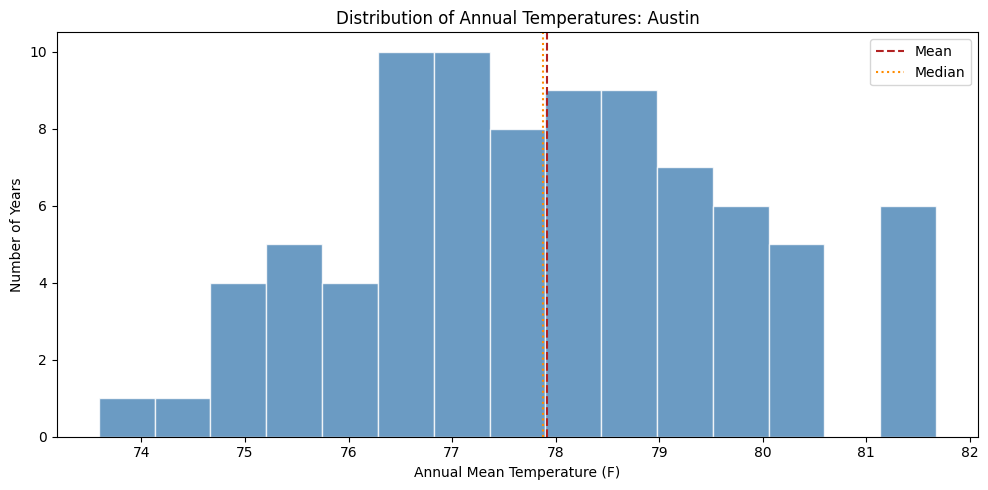

Skewness: 0.083


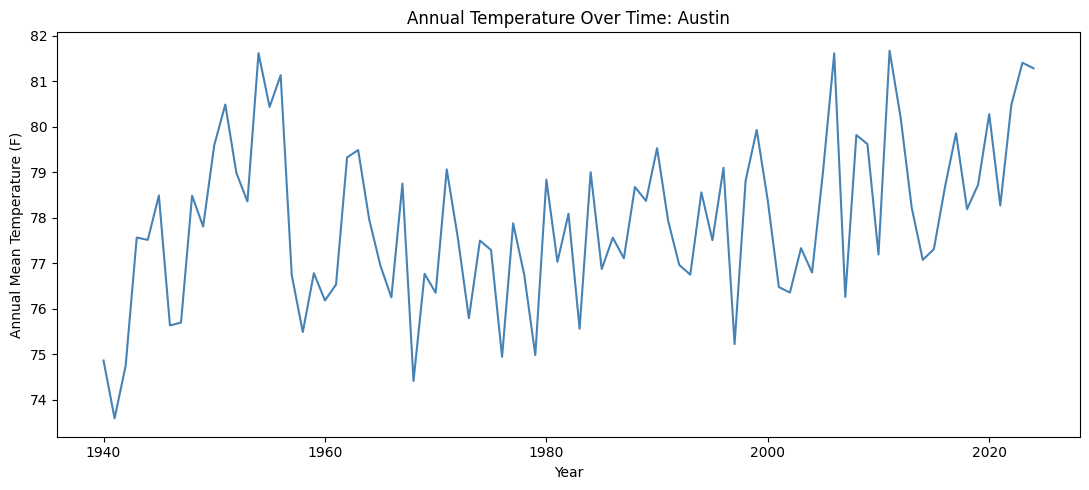

Baseline years: 31
Recent years: 31
Baseline mean temperature: 77.72 F
Baseline standard deviation: 1.87 F
Recent mean temperature: 78.37 F
Recent standard deviation: 1.58 F
Anomaly: 0.65 F


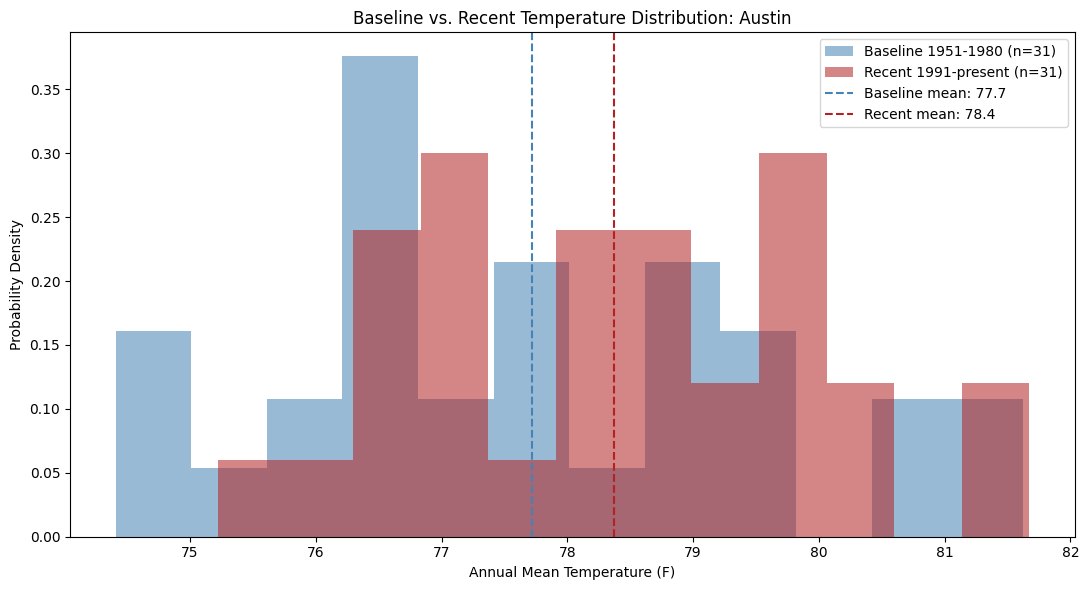

=== BASELINE STATISTICS FOR Austin ===
Baseline period: 1951-1980
Baseline mean: 77.7160
Baseline std: 1.8677
Recent mean: 78.3679
Mean anomaly: 0.6519
Skewness: 0.0832


In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

annual = pd.read_csv('/content/drive/MyDrive/Data Science/Data/annual_summary_austin.csv')
df = pd.read_csv('/content/drive/MyDrive/Data Science/Data/climate_austin.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
print(annual.shape)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(annual['mean_temp_max_f'], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Annual Mean Temperature (F)')
ax.set_ylabel('Number of Years')
ax.set_title('Distribution of Annual Temperatures: Austin')
ax.axvline(annual['mean_temp_max_f'].mean(), color='firebrick', linestyle='--', label='Mean')
ax.axvline(annual['mean_temp_max_f'].median(), color='darkorange', linestyle=':', label='Median')
ax.legend()
plt.tight_layout()
plt.show()


from scipy import stats
skew_val = stats.skew(annual['mean_temp_max_f'].dropna())
print(f'Skewness: {skew_val:.3f}')


fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(annual['year'], annual['mean_temp_max_f'], color='steelblue', linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Mean Temperature (F)')
ax.set_title('Annual Temperature Over Time: Austin')
plt.tight_layout()
plt.show()

# Define baseline and recent years for comparison
baseline = annual[(annual['year'] >= 1950) & (annual['year'] <= 1980)]['mean_temp_max_f']
recent = annual[(annual['year'] >= 1990) & (annual['year'] <= 2020)]['mean_temp_max_f']

print(f'Baseline years: {len(baseline)}')
print(f'Recent years: {len(recent)}')
baseline_mean = baseline.mean()
baseline_std = baseline.std()
print(f'Baseline mean temperature: {baseline_mean:.2f} F')
print(f'Baseline standard deviation: {baseline_std:.2f} F')

recent_mean = recent.mean()
recent_std = recent.std()
print(f'Recent mean temperature: {recent_mean:.2f} F')
print(f'Recent standard deviation: {recent_std:.2f} F')
print(f'Anomaly: {recent.mean() - baseline_mean:.2f} F')


fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(baseline.dropna(), bins=12, density=True, alpha=0.55, color='steelblue', label=f'Baseline 1951-1980 (n={len(baseline)})')
ax.hist(recent.dropna(), bins=12, density=True, alpha=0.55, color='firebrick', label=f'Recent 1991-present (n={len(recent)})')
ax.axvline(baseline_mean, color='steelblue', linestyle='--', linewidth=1.5, label=f'Baseline mean: {baseline_mean:.1f}')
ax.axvline(recent.mean(), color='firebrick', linestyle='--', linewidth=1.5, label=f'Recent mean: {recent.mean():.1f}')
ax.set_xlabel('Annual Mean Temperature (F)')
ax.set_ylabel('Probability Density')
ax.set_title('Baseline vs. Recent Temperature Distribution: Austin')
ax.legend()
plt.tight_layout()
plt.show()


print('=== BASELINE STATISTICS FOR Austin ===')
print(f'Baseline period: 1951-1980')
print(f'Baseline mean: {baseline_mean:.4f}')
print(f'Baseline std: {baseline_std:.4f}')
print(f'Recent mean: {recent.mean():.4f}')
print(f'Mean anomaly: {recent.mean() - baseline_mean:.4f}')
print(f'Skewness: {skew_val:.4f}')


In [4]:
import json

# Create a dictionary to hold the baseline statistics
baseline_stats = {
    'baseline_mean': baseline_mean,
    'baseline_std': baseline_std
}

# Define the filename for the JSON file
json_filename = 'austin_baseline_stats.json'

# Write the dictionary to a JSON file
with open(json_filename, 'w') as f:
    json.dump(baseline_stats, f, indent=4)

print(f'Baseline statistics saved to {json_filename}')

Baseline statistics saved to austin_baseline_stats.json
